# ATE Phase 2 — Gate Classifier ONLY (chạy song song với ATE notebook)

**Mục đích:** Chạy notebook này trên **Tab Colab #1 (T4)** song song với `ate_phase2_ate_only.ipynb` trên Tab #2.

**Pipeline:**
1. Tải 5 file high confidence qua `gdown` → sample 400k/cat
2. Kết hợp với gold train, loại leakage
3. Save `train_df` lên Drive để ATE notebook dùng chung
4. Huấn luyện **Gate Classifier** (roberta-base)
5. Đánh giá trên gold test (threshold sweep 0.0–0.9)

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q transformers==4.46.0 accelerate==0.34.0 datasets seqeval scikit-learn pyarrow pandas tqdm matplotlib gdown


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 122.2 MB/s eta 0:00:00


In [3]:
import os

GOLD_TRAIN_PATH = "/content/drive/MyDrive/dataset_gold/gold_train.csv"
GOLD_TEST_PATH  = "/content/drive/MyDrive/dataset_gold/gold_test.csv"

PHASE2_DIR       = "/content/drive/MyDrive/output_cleaning/absa_self_train_phase2"
GATE_SAVE_PATH   = f"{PHASE2_DIR}/ate_gate_phase2"
REPORT_DIR       = f"{PHASE2_DIR}/reports"
# Shared: save train_df ở đây để ATE notebook load → không cần tải lại 2M samples
SHARED_TRAIN_PARQUET = f"{PHASE2_DIR}/shared_train_df.parquet"

os.makedirs(GATE_SAVE_PATH, exist_ok=True)
os.makedirs(REPORT_DIR,     exist_ok=True)
os.makedirs(PHASE2_DIR,     exist_ok=True)

CATEGORIES           = ["electronics_p1", "electronics_p2", "software", "kindle_store", "office_products"]
SAMPLES_PER_CATEGORY = 400_000
RANDOM_SEED          = 1234

HIGH_CONF_GDRIVE_IDS = {
    "electronics_p1" : "1nDYriP7FgAS8gCxQYGMPwGkwOuWM6mRR",
    "electronics_p2" : "1I1Vn29wx5RQ28BqXudbQphikNEbMThgE",
    "software"       : "1L1Q5zYY_XGUiPclTrap4ssnH8nhKUY8R",
    "kindle_store"   : "1H4QWm_eR37k3h2mivEjWa1j3HP_zBlkr",
    "office_products": "1lvpFGj-zYomh7y2rMNoboqCHNYloAu0s",
}

MODEL_NAME  = "roberta-base"
MAX_LENGTH  = 192
GATE_EPOCHS = 3
GATE_BS     = 64
LEARNING_RATE   = 2e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
GRAD_ACCUM      = 2
DATALOADER_WORKERS = 2
SAVE_TOTAL_LIMIT   = 1
EVAL_THRESHOLDS = [round(t * 0.1, 1) for t in range(10)]

print(f"GATE_BS : {GATE_BS}  (effective {GATE_BS * GRAD_ACCUM})")


GATE_BS : 64  (effective 128)


In [4]:
import ast, pandas as pd

def parse_aspects_col(series):
    def _parse(val):
        # Handle list / numpy array / other iterables (but not str)
        if hasattr(val, '__iter__') and not isinstance(val, str):
            return [a for a in val if a and str(a).strip()]
        # Scalar: check for NA
        try:
            if pd.isna(val):
                return []
        except (TypeError, ValueError):
            pass
        s = str(val).strip()
        if s in ("", "[]", "nan"):
            return []
        try:
            return [a for a in ast.literal_eval(s) if a and str(a).strip()]
        except Exception:
            return []
    return series.apply(_parse)

gold_train = pd.read_csv(GOLD_TRAIN_PATH)
gold_test  = pd.read_csv(GOLD_TEST_PATH)
gold_train["aspects"] = parse_aspects_col(gold_train["aspects"])
gold_test["aspects"]  = parse_aspects_col(gold_test["aspects"])
gold_test_sentences   = set(gold_test["sentence_text"].str.strip().str.lower())
print(f"Gold train: {len(gold_train):,} | Gold test: {len(gold_test):,}")


Gold train: 3,200 | Gold test: 800


In [5]:
import pyarrow.parquet as pq, pyarrow as pa, numpy as np, gdown, gc, zipfile

LOCAL_HC_DIR = "/content/high_conf"
os.makedirs(LOCAL_HC_DIR, exist_ok=True)
rng = np.random.default_rng(RANDOM_SEED)
hc_frames = []

# Cột bắt buộc (luôn có) và cột tùy chọn (có thể vắng trong một số file)
_REQUIRED = ["parent_asin","sentence_id","sentence_text",
             "rating","gate_confidence","aspects","confidences"]
_OPTIONAL = ["category_name"]

def _read_hc_parquet(path, n_samples=None, rng=None):
    """
    Đọc parquet theo row-group level sampling:
    - Lấy metadata để biết kích thước từng row group (không đọc data)
    - Shuffle thứ tự row group, chọn đến khi đủ ≥ n_samples dòng rồi dừng
    - Chỉ đọc đúng những row group được chọn → phần còn lại không vào RAM/disk I/O
    - Sub-sample xuống đúng n_samples nếu số dòng vượt quá
    - Cast string → large_utf8 để tránh 2GB offset overflow
    """
    pf      = pq.ParquetFile(path)
    present = set(pf.schema_arrow.names)
    cols    = _REQUIRED + [c for c in _OPTIONAL if c in present]

    def _cast_table(tbl):
        new_cols, fields = {}, []
        for i, field in enumerate(tbl.schema):
            arr = tbl.column(i)
            if arr.type == pa.string():
                arr = arr.cast(pa.large_utf8())
            elif arr.type == pa.list_(pa.string()):
                arr = arr.cast(pa.list_(pa.large_utf8()))
            new_cols[field.name] = arr
            fields.append(pa.field(field.name, arr.type))
        return pa.table(new_cols, schema=pa.schema(fields))

    if n_samples is not None and rng is not None:
        meta       = pf.metadata
        n_rg       = meta.num_row_groups
        rg_sizes   = [meta.row_group(i).num_rows for i in range(n_rg)]
        total_rows = sum(rg_sizes)
        actual_n   = min(n_samples, total_rows)

        # Shuffle thứ tự row group → chọn ngẫu nhiên cho đến khi đủ dòng
        rg_order = rng.permutation(n_rg).tolist()
        selected_rgs, accumulated = [], 0
        for rg_idx in rg_order:
            selected_rgs.append(rg_idx)
            accumulated += rg_sizes[rg_idx]
            if accumulated >= actual_n:
                break  # ← dừng sớm, không đọc thêm bất kỳ row group nào

        # Đọc từng row group đã chọn (mỗi lần ~50-100k dòng), xong xóa ngay
        tables = []
        for rg_idx in selected_rgs:
            tbl = pf.read_row_group(rg_idx, columns=cols)
            tables.append(_cast_table(tbl))
            del tbl

        table = pa.concat_tables(tables)
        del tables

        # Sub-sample xuống đúng actual_n nếu accumulated vượt quá
        if len(table) > actual_n:
            sub_idx = np.sort(rng.choice(len(table), size=actual_n, replace=False))
            table   = table.take(sub_idx)
    else:
        # Fallback: đọc toàn bộ file
        tables = []
        for batch in pf.iter_batches(columns=cols, batch_size=100_000):
            tables.append(_cast_table(pa.Table.from_batches([batch])))
        table = pa.concat_tables(tables)
        del tables

    # Thêm cột optional còn thiếu dưới dạng null
    for c in _OPTIONAL:
        if c not in present:
            table = table.append_column(
                c, pa.array([None] * len(table), type=pa.large_utf8()))
    return table

def _ensure_parquet(local_path, file_id, cat):
    """
    Tải file và đảm bảo đầu ra là file parquet hợp lệ.
    Xử lý trường hợp Google Drive trả về ZIP (magic=PK\\x03\\x04).
    Trả về True nếu thành công, False nếu thất bại.
    """
    for attempt in range(2):
        if not os.path.exists(local_path):
            gdown.download(id=file_id, output=local_path, quiet=False, fuzzy=True)

        try:
            with open(local_path, "rb") as fh:
                magic = fh.read(4)
        except Exception as e:
            print(f"  [VALIDATE ERROR] {cat}: {e}"); return False

        if magic == b"PAR1":
            return True  # file hợp lệ

        if magic == b"PK\x03\x04":
            # Google Drive zip file lớn khi download → giải nén lấy .parquet bên trong
            print(f"  [ZIP] {cat}: Google Drive trả về ZIP, đang giải nén...")
            try:
                extracted = local_path + ".extracted.parquet"
                with zipfile.ZipFile(local_path, "r") as zf:
                    names = [n for n in zf.namelist() if n.endswith(".parquet")]
                    if not names:
                        raise ValueError(f"Không tìm thấy .parquet trong ZIP: {zf.namelist()}")
                    with zf.open(names[0]) as src, open(extracted, "wb") as dst:
                        dst.write(src.read())
                os.replace(extracted, local_path)
                with open(local_path, "rb") as fh:
                    magic = fh.read(4)
                if magic == b"PAR1":
                    print(f"  [ZIP] {cat}: giải nén thành công.")
                    return True
            except Exception as e:
                print(f"  [ZIP ERROR] {cat}: {e}")

        # File vẫn không hợp lệ → xóa và thử lại lần 2
        print(f"  [INVALID] {cat}: magic={magic}, xóa và tải lại (lần {attempt+1})...")
        os.remove(local_path)

    print(f"  [FAILED] {cat}: không tải được file parquet hợp lệ sau 2 lần thử.")
    return False

for cat in CATEGORIES:
    file_id    = HIGH_CONF_GDRIVE_IDS[cat]
    local_path = f"{LOCAL_HC_DIR}/{cat}.parquet"

    if not _ensure_parquet(local_path, file_id, cat):
        continue

    # Lọc 400k theo row-group sampling — chỉ đọc phần cần thiết
    try:
        df = _read_hc_parquet(local_path, n_samples=SAMPLES_PER_CATEGORY, rng=rng).to_pandas()
        gc.collect()
    except Exception as e:
        print(f"  [READ ERROR] {cat}: {e}"); continue

    df["aspects"] = parse_aspects_col(df["aspects"])

    # Điền category_name còn thiếu (vd: kindle_store không có cột này trong file gốc)
    missing_mask = df["category_name"].isna() | (df["category_name"].astype(str).str.strip() == "")
    if missing_mask.any():
        df.loc[missing_mask, "category_name"] = cat
        print(f"  {cat:20s}: filled {missing_mask.sum():,} missing category_name → '{cat}'")

    hc_frames.append(df)
    print(f"  {cat:20s}: sampled={len(df):>8,}")
    del df; gc.collect()

high_conf_df = pd.concat(hc_frames, ignore_index=True)
del hc_frames; gc.collect()
print(f"Total high conf: {len(high_conf_df):,}")


Downloading...
From (original): https://drive.google.com/uc?id=1nDYriP7FgAS8gCxQYGMPwGkwOuWM6mRR
From (redirected): https://drive.google.com/uc?id=1nDYriP7FgAS8gCxQYGMPwGkwOuWM6mRR&confirm=t&uuid=64736095-cc26-47f1-91ef-1b95acd34494
To: /content/high_conf/electronics_p1.parquet
100%|██████████| 212M/212M [00:05<00:00, 38.2MB/s]


  electronics_p1      : sampled= 400,000


Downloading...
From (original): https://drive.google.com/uc?id=1I1Vn29wx5RQ28BqXudbQphikNEbMThgE
From (redirected): https://drive.google.com/uc?id=1I1Vn29wx5RQ28BqXudbQphikNEbMThgE&confirm=t&uuid=ad53d9be-87c8-48db-be3b-76ee6608c97a
To: /content/high_conf/electronics_p2.parquet
100%|██████████| 1.97G/1.97G [00:17<00:00, 110MB/s]


  electronics_p2      : sampled= 400,000


Downloading...
From: https://drive.google.com/uc?id=1L1Q5zYY_XGUiPclTrap4ssnH8nhKUY8R
To: /content/high_conf/software.parquet
100%|██████████| 48.8M/48.8M [00:00<00:00, 69.0MB/s]


  software            : sampled= 400,000


Downloading...
From (original): https://drive.google.com/uc?id=1H4QWm_eR37k3h2mivEjWa1j3HP_zBlkr
From (redirected): https://drive.google.com/uc?id=1H4QWm_eR37k3h2mivEjWa1j3HP_zBlkr&confirm=t&uuid=7520fc2a-504b-4992-9cda-559125911722
To: /content/high_conf/kindle_store.parquet
100%|██████████| 236M/236M [00:02<00:00, 117MB/s] 


  kindle_store        : filled 400,000 missing category_name → 'kindle_store'
  kindle_store        : sampled= 400,000


Downloading...
From (original): https://drive.google.com/uc?id=1lvpFGj-zYomh7y2rMNoboqCHNYloAu0s
From (redirected): https://drive.google.com/uc?id=1lvpFGj-zYomh7y2rMNoboqCHNYloAu0s&confirm=t&uuid=1f82f001-b29c-4ce5-b4e5-93704901657e
To: /content/high_conf/office_products.parquet
100%|██████████| 171M/171M [00:02<00:00, 76.6MB/s]


  office_products     : sampled= 400,000
Total high conf: 2,000,000


In [6]:
train_df  = pd.concat([high_conf_df, gold_train], ignore_index=True)
del high_conf_df; gc.collect()  # giải phóng ~2GB trước khi xử lý tiếp

before    = len(train_df)
mask_leak = train_df["sentence_text"].str.strip().str.lower().isin(gold_test_sentences)
train_df  = train_df[~mask_leak].reset_index(drop=True)
n_removed = before - len(train_df)
train_df  = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Final train: {len(train_df):,}  (removed {n_removed:,} leakage)")

# ── Save train_df để ATE notebook dùng chung ─────────────────────────────
train_df_save = train_df.copy()
# Serialize các cột có kiểu mixed (list vs string) thành str cho đồng nhất
train_df_save["aspects"]     = train_df_save["aspects"].apply(str)
train_df_save["confidences"] = train_df_save["confidences"].apply(str)
train_df_save["sentence_id"] = train_df_save["sentence_id"].astype(str)
train_df_save["rating"]      = pd.to_numeric(train_df_save["rating"], errors="coerce")
train_df_save.to_parquet(SHARED_TRAIN_PARQUET, index=False)
del train_df_save; gc.collect()
print(f"Shared train_df saved → {SHARED_TRAIN_PARQUET}")
print("ATE notebook có thể bắt đầu khi file này xuất hiện trên Drive.")


Final train: 1,998,886  (removed 4,314 leakage)
Shared train_df saved → /content/drive/MyDrive/output_cleaning/absa_self_train_phase2/shared_train_df.parquet
ATE notebook có thể bắt đầu khi file này xuất hiện trên Drive.


In [7]:
import re, torch

TOKEN_RE = re.compile(r"\b\w+(?:'\w+)?\b")

def clean_text(text):
    if pd.isna(text): return ""
    return re.sub(r"\s+", " ", str(text)).strip()

def tokenize_words(text):
    return [m.group(0) for m in TOKEN_RE.finditer(text)]

In [8]:
from torch.utils.data import Dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
from tqdm.auto import tqdm as tqdm_auto

# Nếu train_df đã bị xóa hoặc kernel restart → load lại từ parquet đã lưu
if "train_df" not in globals():
    print("train_df không có trong memory, load lại từ shared parquet...")
    train_df = pd.read_parquet(SHARED_TRAIN_PARQUET)
    train_df["aspects"] = parse_aspects_col(train_df["aspects"])
    print(f"  Loaded: {len(train_df):,} rows")

gate_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class GateDataset(Dataset):
    """
    Pre-tokenize toàn bộ → lưu dạng Python list (không padding → tiết kiệm RAM).
    __getitem__ chỉ index + to_tensor → nhanh trong DataLoader workers.
    """
    def __init__(self, df, tokenizer, max_length=192, chunk_size=10_000):
        texts  = [clean_text(t) for t in df["sentence_text"]]
        self._labels = [1 if len(a) > 0 else 0 for a in df["aspects"]]
        self._input_ids, self._attention_mask = [], []
        for start in tqdm_auto(range(0, len(texts), chunk_size), desc="tokenize gate"):
            enc = tokenizer(
                texts[start:start + chunk_size],
                truncation=True, max_length=max_length, padding=False,
            )
            self._input_ids.extend(enc["input_ids"])
            self._attention_mask.extend(enc["attention_mask"])
    def __len__(self): return len(self._labels)
    def __getitem__(self, idx):
        return {
            "input_ids"     : torch.tensor(self._input_ids[idx],      dtype=torch.long),
            "attention_mask": torch.tensor(self._attention_mask[idx], dtype=torch.long),
            "labels"        : torch.tensor(self._labels[idx],          dtype=torch.long),
        }

print("Building Gate train dataset...")
gate_train_ds = GateDataset(train_df, gate_tokenizer, MAX_LENGTH)
print("Building Gate eval dataset...")
gate_eval_ds  = GateDataset(gold_test, gate_tokenizer, MAX_LENGTH)
n_pos = sum(1 for a in train_df["aspects"] if len(a) > 0)
n_neg = len(train_df) - n_pos
pos_weight = n_neg / n_pos
print(f"Gate train: {len(gate_train_ds):,} | pos_weight={pos_weight:.4f}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Building Gate train dataset...


tokenize gate:   0%|          | 0/200 [00:00<?, ?it/s]

Building Gate eval dataset...


tokenize gate:   0%|          | 0/1 [00:00<?, ?it/s]

Gate train: 1,998,886 | pos_weight=0.7454


In [9]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from scipy.special import softmax as scipy_softmax

# Giải phóng train_df trước khi load model
if "train_df" in globals():
    del train_df; gc.collect()

device = "cuda" if torch.cuda.is_available() else "cpu"

# Phát hiện SM version để chọn precision đúng
# bf16 hardware: Ampere (SM 8.0+) trở lên — A100, RTX 3090, ...
# T4 = SM 7.5 → KHÔNG có hardware bf16 → phải dùng fp16
_sm           = torch.cuda.get_device_capability() if device == "cuda" else (0, 0)
_has_bf16_hw  = (_sm[0] > 8) or (_sm[0] == 8 and _sm[1] >= 0)  # SM >= 8.0
_use_bf16     = device == "cuda" and _has_bf16_hw
_use_fp16     = device == "cuda" and not _use_bf16
_use_compile  = device == "cuda" and _has_bf16_hw  # torch.compile lợi ích từ SM 8+
_optim        = "adamw_torch_fused" if device == "cuda" else "adamw_torch"

print(f"Device={device} | SM={_sm} | has_bf16_hw={_has_bf16_hw} | "
      f"fp16={_use_fp16} | bf16={_use_bf16} | compile={_use_compile}")

gate_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

class WeightedGateTrainer(Trainer):
    def __init__(self, pos_weight, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight_val = pos_weight
    def compute_loss(self, model, inputs, return_outputs=False, **_kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        weights = torch.tensor([1.0, self.pos_weight_val], device=outputs.logits.device)
        loss    = torch.nn.CrossEntropyLoss(weight=weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_gate_metrics(eval_pred):
    logits, labels = eval_pred
    probs = scipy_softmax(logits, axis=-1)[:, 1]
    preds = (probs >= 0.5).astype(int)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

gate_args = TrainingArguments(
    output_dir=f"{PHASE2_DIR}/gate_checkpoints",
    num_train_epochs=GATE_EPOCHS,
    per_device_train_batch_size=GATE_BS,
    per_device_eval_batch_size=GATE_BS * 4,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=SAVE_TOTAL_LIMIT,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=500,
    fp16=_use_fp16, bf16=_use_bf16, optim=_optim,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    group_by_length=True,
    dataloader_num_workers=DATALOADER_WORKERS,
    dataloader_pin_memory=(device == "cuda"),
    torch_compile=_use_compile,
    report_to="none",
)

gate_trainer = WeightedGateTrainer(
    pos_weight=pos_weight, model=gate_model, args=gate_args,
    train_dataset=gate_train_ds, eval_dataset=gate_eval_ds,
    compute_metrics=compute_gate_metrics,
    data_collator=DataCollatorWithPadding(gate_tokenizer),
)
print("Starting Gate training...")
gate_trainer.train()


Device=cuda | SM=(7, 5) | has_bf16_hw=False | fp16=True | bf16=False | compile=False


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Starting Gate training...


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
0,0.081700,1.205526,0.822500,0.785714,0.944934,0.858000
2,0.027900,1.396327,0.836250,0.813592,0.922907,0.864809


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


TrainOutput(global_step=46848, training_loss=0.0738290308521745, metrics={'train_runtime': 12257.6565, 'train_samples_per_second': 489.217, 'train_steps_per_second': 3.822, 'total_flos': 7.18746893536662e+16, 'train_loss': 0.0738290308521745, 'epoch': 2.9999039477475744})

In [10]:
gate_trainer.save_model(GATE_SAVE_PATH)
gate_tokenizer.save_pretrained(GATE_SAVE_PATH)
print(f"Gate model saved → {GATE_SAVE_PATH}")

Gate model saved → /content/drive/MyDrive/output_cleaning/absa_self_train_phase2/ate_gate_phase2


## Đánh Giá Gate — Threshold Sweep

In [11]:
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

eval_gate_tokenizer = AutoTokenizer.from_pretrained(GATE_SAVE_PATH, use_fast=True)
eval_gate_model     = AutoModelForSequenceClassification.from_pretrained(GATE_SAVE_PATH).to(device)
if device == "cuda": eval_gate_model.half()
eval_gate_model.eval()

EVAL_BATCH = 256 if device == "cuda" else 64

def predict_gate_proba_eval(sentences, batch_size=EVAL_BATCH):
    probs_all = []
    for i in tqdm(range(0, len(sentences), batch_size), desc="gate inference"):
        batch = sentences[i:i + batch_size]
        enc   = eval_gate_tokenizer(batch, truncation=True, max_length=MAX_LENGTH, padding=True, return_tensors="pt").to(device)
        with torch.inference_mode():
            probs = torch.softmax(eval_gate_model(**enc).logits.float(), dim=-1)[:, 1].cpu().numpy()
        probs_all.extend(probs.tolist())
    return np.array(probs_all)

test_sentences   = [clean_text(t) for t in gold_test["sentence_text"]]
test_gate_true   = np.array([1 if len(a) > 0 else 0 for a in gold_test["aspects"]])
test_gate_probs  = predict_gate_proba_eval(test_sentences)

gate_threshold_results = []
print(f"{'─'*80}")
print(f"{'Threshold':>12}  {'Accuracy':>10}  {'Precision':>10}  {'Recall':>10}  {'F1':>10}")
print(f"{'─'*80}")
for t in EVAL_THRESHOLDS:
    preds = (test_gate_probs >= t).astype(int)
    acc   = accuracy_score(test_gate_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(test_gate_true, preds, average="binary", zero_division=0)
    gate_threshold_results.append({"threshold": t, "accuracy": round(acc,4), "precision": round(prec,4), "recall": round(rec,4), "f1": round(f1,4)})
    print(f"  {t:>10.1f}  {acc:>10.4f}  {prec:>10.4f}  {rec:>10.4f}  {f1:>10.4f}")

gate_result_df = pd.DataFrame(gate_threshold_results)
best = gate_result_df.loc[gate_result_df["f1"].idxmax()]
print(f"\nBest threshold: {best['threshold']}  F1={best['f1']:.4f}")

gate inference:   0%|          | 0/4 [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────
   Threshold    Accuracy   Precision      Recall          F1
────────────────────────────────────────────────────────────────────────────────
         0.0      0.5675      0.5675      1.0000      0.7241
         0.1      0.8350      0.8084      0.9295      0.8648
         0.2      0.8387      0.8143      0.9273      0.8671
         0.3      0.8400      0.8171      0.9251      0.8678
         0.4      0.8425      0.8203      0.9251      0.8696
         0.5      0.8438      0.8219      0.9251      0.8705
         0.6      0.8450      0.8248      0.9229      0.8711
         0.7      0.8462      0.8290      0.9185      0.8715
         0.8      0.8438      0.8297      0.9119      0.8688
         0.9      0.8475      0.8360      0.9097      0.8713

Best threshold: 0.7  F1=0.8715


Saved: /content/drive/MyDrive/output_cleaning/absa_self_train_phase2/reports/gate_threshold_table.png


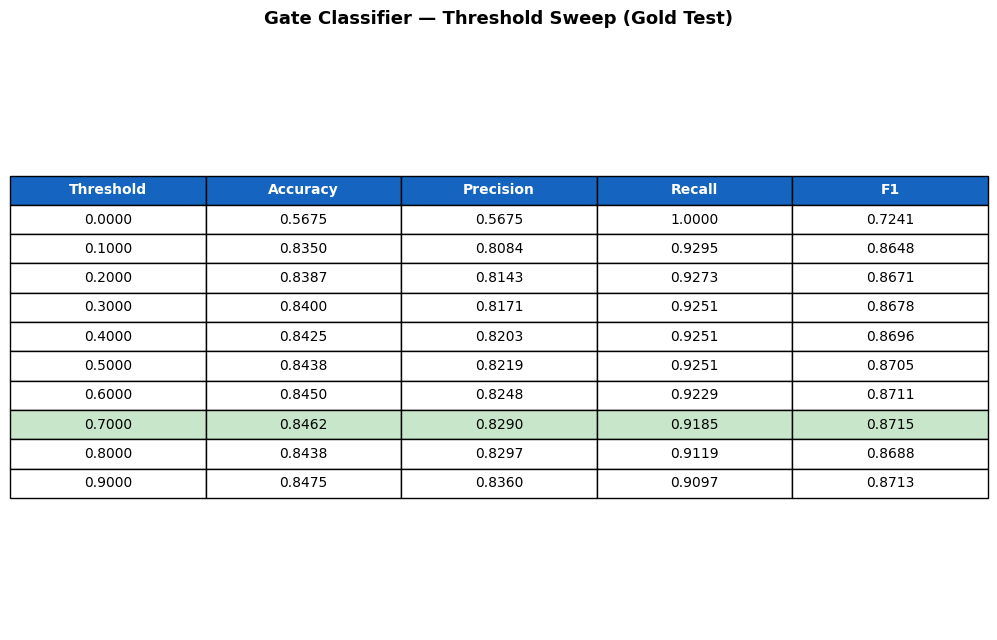

In [12]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"font.size": 10})

def make_table_figure(df, title, col_labels, save_path):
    cell_text = [[f"{v:.4f}" if isinstance(v, float) else str(v) for v in row] for _, row in df.iterrows()]
    fig, ax   = plt.subplots(figsize=(10, len(df) * 0.5 + 1.5))
    ax.axis("off")
    tbl = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
    best_row = int(df["f1"].idxmax())
    for c in range(len(col_labels)): tbl[best_row + 1, c].set_facecolor("#c8e6c9")
    for c in range(len(col_labels)): tbl[0, c].set_facecolor("#1565c0"); tbl[0, c].set_text_props(color="white", fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    fig.tight_layout(); fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_path}"); plt.show()

make_table_figure(
    gate_result_df,
    title="Gate Classifier — Threshold Sweep (Gold Test)",
    col_labels=["Threshold", "Accuracy", "Precision", "Recall", "F1"],
    save_path=f"{REPORT_DIR}/gate_threshold_table.png",
)
